In [ ]:
import subprocess, sys

_pkgs = ["kagglehub", "numpy", "pandas", "seaborn", "matplotlib", "scikit-learn", "xgboost", "lightgbm"]
try:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *_pkgs])
except Exception:
    subprocess.check_call(["uv", "pip", "install", *_pkgs])

import marimo as mo
import os
import shap
import kagglehub
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython import display
from functools import partial

from sklearn.base import clone, BaseEstimator
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, RobustScaler, StandardScaler, LabelEncoder
from sklearn.inspection import permutation_importance

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, VotingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

CONFIG = {
    "SEED": 42,
}

/home/seang/Desktop/Data-Science/Playground-Series/PSS6E7-Student-Health-Prediction/.venv/bin/python3: No module named pip
Checked 8 packages in 5ms


# PS-S6E7 | Predicting Student Health Risk: A Guided Walkthrough
This write-up covers a simple approach to the Kaggle Playground Series competition "Predicting Student Health Risk" (Season 6, Episode 7).

## About the dataset
This dataset is a comprehensive student health dataset containing 50,000 records, created to capture the wide-ranging lifestyle, physiological, and psychological characteristics of college students. It is modeled on trends observed in large-scale student health studies conducted in China, ensuring realistic variation in daily habits and health-related attributes. The dataset integrates information collected from surveys, wearable devices, and institutional health records, encompassing lifestyle behaviors, psychological indicators, and time-series data.

Each record corresponds to a time-stamped observation, capturing how student habits and conditions change over time. The dataset integrates multiple dimensions of health, including physical activity, sleep behavior, mental well-being, Chronic Fatigue, and academic influences, providing a comprehensive view of factors affecting student health.

## Feature information

1. **Categorical**
    - `health_condition` - Target variable. Overall health classification of the student: Fit/At-Risk/Unhealthy
    - `diet_type` - The student's general eating pattern/category (e.g., balanced, high-carb, protein, junk food, vegetarian, etc.).
    - `smoking_alcohol` - Indicates whether the student smokes and/or consumes alcohol (e.g., None, Smoking only, Alcohol only, Both).
    - `gender` - The student's gender (e.g., Male, Female, Other).

2. **Ordinal**
    - `sleep_quality` - A ranked rating of how restful/effective the student's sleep is (e.g., Poor -> Fair -> Good -> Excellent).
    - `physical_activity_level` - A ranked category of how physically active the student is overall (e.g., Sedentary -> Light -> Moderate-> Active -> Very Active).
    - `stress_level` - A ranked measure of the student's perceived stress (e.g., Low -> Moderate -> High -> Severe).

3. **Numerical**
    - `sleep_duration` - Total hours of sleep per night.
    - `heart_rate` - Resting or average heart rate in beats per minute (bpm).
    - `bmi` - Body Mass Index.
    - `calorie_expenditure` - Estimated total calories burned per day.
    - `step_count` - Number of steps take per day.
    - `exercise_duration` - Total minutes spent in dedicated exercise/workout sessions per day.
    - `water_intake` - Daily water consumption.

## Learning Objectives

By the end of this notebook, you will be able to:

1. **Choose appropriate evaluation metrics** for imbalanced classification problems
2. **Implement balanced accuracy** from scratch to understand how it differs from plain accuracy
3. **Apply stratified K-Fold cross-validation** to get reliable performance estimates with imbalanced classes
4. **Use class weighting** to handle severe class imbalance during model training
5. **Compare model families** under controlled conditions to identify the best performer
6. **Engineer features** to expose signal hidden in the raw representation
7. **Interpret model predictions** using SHAP values to understand feature importance
8. **Build a complete ML pipeline** from EDA through submission

## Utilities

### `Preprocessor`

In [ ]:
class Preprocessor:
    def __init__(
        self,
        data: pd.DataFrame,
        target: str = None,
        drop_id: bool = True,
        drop_nan: bool = False,
        drop_duplicates: bool = False,
        verbose=False,
    ):
        """Preprocessor class for cleaning, splitting, and transforming datasets.

        Supports both training data (with target) and unseen test data (without
        target).
        """
        self._data = data.copy()

        if drop_nan:
            _before = self._data.shape[0]
            self._data.dropna(inplace=True)
            _after = self._data.shape[0]
            if verbose:
                self._display_reduction(_before, _after, "nan")
        self._drop_nan = drop_nan

        if drop_duplicates:
            _before = self._data.shape[0]
            self._data.drop_duplicates(inplace=True)
            _after = self._data.shape[0]
            if verbose:
                self._display_reduction(_before, _after, "duplicate")
        self._drop_duplicates = drop_duplicates

        self._target_name = target
        self._target = self._data[target].copy() if target else None

        _exclude = []
        if target:
            _exclude.append(target)
        if drop_id and "id" in self._data.columns:
            _exclude.append("id")
        self._drop_id = drop_id

        if _exclude:
            self._data.drop(columns=_exclude, inplace=True, errors="ignore")

        self._X = {"train": None, "valid": None}
        self._y = {"train": None, "valid": None}

        self._transformer = None
        self._label_encoder = None

        self._split_info = {
            "test_size": 0.0,
            "stratify": False,
            "random_state": 42,
        }

    def _display_reduction(self, before: int, after: int, type_str: str) -> None:
        print(
            f"Preprocessor: Dropping {type_str} values: {before} -> {after} rows (-{((before-after)/before)*100:0.1f}%)"
        )

    def get_data(self) -> None:
        return self._data, self._target

    def get_split(self):
        """Returns transformed features (and target labels if available)."""
        if self._target_name is not None:
            if self._X["train"] is not None:
                return self._X, self._y
            return self._data, self._target
        return self._data

    def get_metadata(self) -> dict:
        return {
            "drop_id": self._drop_id,
            "drop_nan": self._drop_nan,
            "drop_duplicates": self._drop_duplicates,
            "split_info": self._split_info,
            "transformer": self._transformer.transformers_,
            "label_encoder": self._label_encoder
        }

    def split_data(
        self,
        test_size: float = 0.2,
        stratify: bool = True,
        random_state: int = 42,
    ) -> None:
        if self._target is None:
            print("Preprocessor: Cannot split dataset without target column.", file=sys.stderr)
            return

        (
            self._X["train"],
            self._X["valid"],
            self._y["train"],
            self._y["valid"],
        ) = train_test_split(
            self._data,
            self._target,
            test_size=test_size,
            stratify=self._target if stratify else None,
            random_state=random_state,
        )

        self._split_info["test_size"] = test_size
        self._split_info["stratify"] = stratify
        self._split_info["random_state"] = random_state

    def get_classes(self):
        if self._target is None:
            print("Preprocessor: No target specified.", file=sys.stderr)
            return None

        classes = None
        if self._label_encoder is None:
            print(
                "Preprocessor: target has not been encoded yet. Call encode target using `encode_target` method to return encoded labels from fitted label encoder.",
                file=sys.stderr
            )
            classes = self._target.unique().to_numpy()
        else:
            classes = self._label_encoder.classes_

        return classes

    def encode_target(
        self, inplace: bool = True, as_series: bool = True
    ) -> dict:
        """Encodes target strings into integers using a single fitted LabelEncoder."""
        if self._target is None:
            print(
                "Preprocessor: No target present to encode.", file=sys.stderr
            )
            return None

        self._label_encoder = LabelEncoder()

        if self._y["train"] is not None:
            _y = self._y if inplace else self._y.copy()
            _y["train"] = self._label_encoder.fit_transform(_y["train"])
            _y["valid"] = self._label_encoder.transform(_y["valid"])
            if as_series:
                _y["train"] = pd.Series(
                    _y["train"], index=self._X["train"].index, name=self._target_name
                )
                _y["valid"] = pd.Series(
                    _y["valid"], index=self._X["valid"].index, name=self._target_name
                )
            return None if inplace else _y
        else:
            self._target = pd.Series(
                self._label_encoder.fit_transform(self._target),
                index=self._data.index,
                name=self._target_name,
            )
            return None

    def _convert_to_df(
        self, data_array: np.ndarray, transformer: ColumnTransformer
    ) -> pd.DataFrame:
        """Utility using Scikit-Learn's native get_feature_names_out()."""
        try:
            feature_names = transformer.get_feature_names_out()
        except Exception:
            feature_names = [f"feat_{i}" for i in range(data_array.shape[1])]

        return pd.DataFrame(data_array, columns=feature_names)

    def fit(self, transformer: ColumnTransformer):
        """Fit transformer on training data (or full data if no split)."""
        self._transformer = clone(transformer)
        if self._target_name is not None and self._X["train"] is not None:
            self._transformer.fit(self._X["train"])
        else:
            self._transformer.fit(self._data)
        return self

    def transform(self, data=None):
        """Transform data using the fitted transformer.

        - If data is provided: transform that external data and return a DataFrame.
        - If no data: transform all internal data (train + valid, or full) in place.
        """
        if self._transformer is None:
            raise ValueError("No transformer fitted. Call fit() first.")

        if data is not None:
            arr = self._transformer.transform(data)
            return self._convert_to_df(arr, self._transformer)

        if self._target_name is not None and self._X["train"] is not None:
            self._X["train"] = self._convert_to_df(
                self._transformer.transform(self._X["train"]), self._transformer)
            self._X["valid"] = self._convert_to_df(
                self._transformer.transform(self._X["valid"]), self._transformer)
        else:
            self._data = self._convert_to_df(
                self._transformer.transform(self._data), self._transformer)

### `CrossValidator`

In [ ]:
class CrossValidator:
    def __init__(
        self,
        models: list,
        metric_fns: list,
        cv_method,
        name: str = None,
        pi_kwargs: dict = None,
        pred_probs: bool = False,
        adjust_priors: bool = False,
        verbose: bool = True,
        sample_weight_fn=None,
        use_eval_set: bool = False,
        fit_params: dict = None,
        eval_weight_keys: dict = None,
    ):
        self._name = name or self.__class__.__name__
        self._verbose = verbose

        self._models = models
        self._metric_fns = metric_fns
        self._cv_method = cv_method
        self._pi_kwargs = pi_kwargs
        self._pred_probs = pred_probs
        self._adjust_priors = adjust_priors
        self._sample_weight_fn = sample_weight_fn
        self._use_eval_set = use_eval_set
        self._fit_params = fit_params or {}
        self._eval_weight_keys = eval_weight_keys or {}

        self._data = None

        self._perm_imp = None
        self._oof_preds = None
        self._oof_metrics = None
        self._oof_metrics_df = None

    def _compute_priors(self, model, y_train) -> np.ndarray:
        counts = pd.Series(y_train).value_counts(normalize=True)
        return np.array([counts.get(cls, 1e-12) for cls in model.classes_])

    def _predict_model(self, model, X, y_train=None):
        """Generates predictions.

        If adjust_priors=True, evaluates probabilities P(y=k|x), divides by
        priors pi_k, and returns argmax_k(P(y=k|x) / pi_k).
        """
        if self._adjust_priors or self._pred_probs:
            probs = model.predict_proba(X)

            if self._adjust_priors:
                if y_train is None:
                    raise ValueError(
                        "y_train is required to compute priors for adjust_priors=True."
                    )
                priors = self._compute_priors(model, y_train)
                adjusted_probs = probs / (priors + 1e-12)

                if self._pred_probs:
                    return adjusted_probs / np.sum(
                        adjusted_probs, axis=1, keepdims=True
                    )
                return np.argmax(adjusted_probs, axis=1)

            return probs

        # Standard argmax prediction
        return model.predict(X)

    def _index(self, data, idx: np.ndarray):
        if isinstance(data, (pd.DataFrame, pd.Series)):
            return data.iloc[idx]
        return data[idx]

    def _eval_weight_key(self, model) -> str:
        cls_name = type(model).__name__
        if cls_name in self._eval_weight_keys:
            return self._eval_weight_keys[cls_name]
        if cls_name.startswith("XGB"):
            return "sample_weight_eval_set"
        return "eval_sample_weight"

    def _build_fit_kwargs(
        self, model_name, model, x_test=None, y_train=None, y_test=None
    ) -> dict:
        kwargs = dict(self._fit_params)

        if self._sample_weight_fn is not None:
            kwargs["sample_weight"] = self._sample_weight_fn(y_train)

        if self._use_eval_set and x_test is not None and y_test is not None:
            kwargs["eval_set"] = [(x_test, y_test)]
            if model_name == "XGBoost":
                kwargs["verbose"] = False
            if self._sample_weight_fn is not None:
                kwargs[self._eval_weight_key(model)] = [
                    self._sample_weight_fn(y_test)
                ]

        return kwargs

    def _calculate_metrics(self, y_test, y_pred) -> dict:
        results = {}
        for metric_name, metric_fn in self._metric_fns:
            try:
                score = metric_fn(y_test, y_pred)
            except ValueError as e:
                print(
                    f"{self._name}: failed to compute '{metric_name}' — {e}\n",
                    file=sys.stderr,
                )
                continue

            results[metric_name] = score
            if self._verbose:
                print(f" - {metric_name} : {score:.5f}\n")
        return results

    def _cross_validate(self, X, y) -> tuple:
        oof_preds, oof_metrics = {}, {}
        x_data, y_data = [], []
        perm_imp = {}

        if self._verbose:
            print(f"Name: {self._name} | {self._cv_method.n_splits}-Fold\n")

        for idx, (train_idx, test_idx) in enumerate(
            self._cv_method.split(X, y)
        ):
            if self._verbose:
                print(f"Fold {idx}:")
                print("-" * 40 + "\n")

            x_train, x_test = self._index(X, train_idx), self._index(X, test_idx)
            y_train, y_test = self._index(y, train_idx), self._index(y, test_idx)

            x_data.extend(
                x_test.to_numpy()
                if isinstance(x_test, pd.DataFrame)
                else x_test
            )
            y_data.extend(
                y_test.to_numpy()
                if isinstance(y_test, pd.Series)
                else y_test
            )

            for model_name, model in self._models:
                if self._verbose:
                    print(f"Fitting: [{model_name}]\n")

                fit_kwargs = self._build_fit_kwargs(
                    model_name, model, x_test=x_test, y_train=y_train, y_test=y_test
                )
                model.fit(x_train, y_train, **fit_kwargs)

                if model_name not in oof_preds:
                    oof_preds[model_name] = []
                    oof_metrics[model_name] = {}
                    perm_imp[model_name] = []

                # Predict using fold-specific y_train for prior calculations
                y_pred = self._predict_model(model, x_test, y_train=y_train)

                oof_preds[model_name].append(y_pred)

                for metric_name, score in self._calculate_metrics(
                    y_test, y_pred
                ).items():
                    oof_metrics[model_name].setdefault(
                        metric_name, []
                    ).append(score)

                if self._pi_kwargs is not None:
                    if self._verbose:
                        print(" -- Calculating Permutation Importances...\n")
                    try:
                        perm_result = permutation_importance(
                            model, x_test, y_test, **self._pi_kwargs
                        )
                        perm_imp[model_name].append(perm_result.importances)
                    except Exception as e:
                        print(
                            f"{self._name}: permutation importance failed for '{model_name}' — {e}\n",
                            file=sys.stderr,
                        )

        if self._pi_kwargs is not None:
            self._perm_imp = perm_imp

        return oof_preds, oof_metrics, (x_data, y_data)

    def _build_oof_metrics_df(self, metric_dict: dict) -> pd.DataFrame:
        records = {"models": []}
        for model_name, metrics in metric_dict.items():
            records["models"].append(model_name)
            for metric_name, scores in metrics.items():
                records.setdefault(metric_name, []).append(np.mean(scores))
        return pd.DataFrame(records).set_index("models")

    def fit(self, X, y) -> None:
        self._oof_preds, self._oof_metrics, self._data = self._cross_validate(X, y)
        self._oof_metrics_df = self._build_oof_metrics_df(self._oof_metrics)

        fit_kwargs = dict(self._fit_params)
        if self._sample_weight_fn is not None:
            fit_kwargs["sample_weight"] = self._sample_weight_fn(y)

        refitted = []
        for model_name, model in self._models:
            fresh = clone(model)
            fresh.fit(X, y, **fit_kwargs)
            refitted.append((model_name, fresh))
        self._models = refitted

    def predict(self, X_valid, y_train=None) -> dict:
        preds = {}
        for model_name, model in self._models:
            preds[model_name] = self._predict_model(model, X_valid, y_train=y_train)
        return preds

    def get_data(self) -> tuple:
        return (self._oof_preds, self._oof_metrics, self._data)

    def get_metadata(self) -> dict:
        return {
            "name": self._name,
            "n_splits": getattr(self._cv_method, "n_splits", None),
            "pred_probs": self._pred_probs,
            "adjust_priors": self._adjust_priors,
            "pi_kwargs": self._pi_kwargs,
            "sample_weighted": self._sample_weight_fn is not None,
            "use_eval_set": self._use_eval_set,
            "fit_params": self._fit_params,
            "eval_weight_keys": self._eval_weight_keys,
            "models": [name for name, _ in self._models],
            "metrics": [name for name, _ in self._metric_fns],
        }

    def get_oof_metrics_df(self) -> pd.DataFrame:
        return self._oof_metrics_df

    def get_metric_fns(self) -> list:
        return self._metric_fns

    def get_perm_importances(self) -> dict:
        return self._perm_imp

    def get_models(self) -> list:
        return self._models

# Load Data

In [ ]:
"""
If you have a Kaggle API token, uncomment the line below to download the dataset using the KaggleHub API
"""
# kagglehub.login()

try: 
    path = kagglehub.competition_download('playground-series-s6e7')
except Exception as e: 
    print("Failed to download competition data. Manually download the dataset from the competitions page.")
else:
    print(f"-- Downloaded competition data to '{path}' --\n")

main_dir = "playground-series-s6e7"

try:
    train_data = pd.read_csv(f"{main_dir}/train.csv")
    test_data = pd.read_csv(f"{main_dir}/test.csv")
    sample_sub = pd.read_csv(f"{main_dir}/sample_submission.csv")
except FileNotFoundError:
    print(f"Failed to load data. Ensure that '{main_dir}' exists in your current working directory.")
else: 
    print(f"-- '{main_dir}' found. Loaded '{main_dir}' successfully --")

sns.set_theme(style="darkgrid", palette="Set2")

-- Downloaded competition data to '/home/seang/.cache/kagglehub/competitions/playground-series-s6e7' --

-- 'playground-series-s6e7' found. Loaded 'playground-series-s6e7' successfully --


In [ ]:
ord_map = {
    'sleep_quality': ["poor", "average", "good"],
    "physical_activity_level": ["sedentary", "moderate", "active"],
    "stress_level": ["low", "medium", "high"]
}

ord_categories = list(ord_map.values())

ord_cols = list(ord_map.keys())
num_cols = train_data.select_dtypes(include=[np.number]).columns.tolist()[1:]

# Categorical 
cat_cols = []
for _col in train_data.select_dtypes(exclude=[np.number]).columns.tolist():
    if (_col not in ord_cols) and _col != "health_condition":
        cat_cols.append(_col)

metric_fns = [
    ("balanced_accuracy", balanced_accuracy_score),
    ("macro_f1 ", partial(f1_score, average="macro")), 
]

# 1. Exploratory Data Analysis
EDA allows practitioners to spot structural flaws like severe class imbalances and systematic missingness patterns early, directly dictating whether standard metrics are appropriate or if specialized evaluation strategies like Balanced Accuracy are required. Furthermore, analyzing feature distributions across target classes uncovers linear and non-linear separability, which justifies model choice (e.g., Logistic Regression vs. LightGBM) and guides essential preprocessing decisions such as scaling, imputation, and post-processing adjustments.

## First glances at the data

In [ ]:
train_data.head()

In [ ]:
test_data.head()

In [ ]:
train_data.describe()

In [ ]:
test_data.describe()

In [ ]:
train_data.info()

In [ ]:
test_data.info()

## Target Analysis

Start with the target. `health_condition` classifies each student into one of three buckets: `fit`, `at-risk`, or `unhealthy`. Let's look at how these three classes are distributed in the training data.

### Target Distribution

In [ ]:
classes = train_data["health_condition"].unique().tolist()
class_cnts = {cls : len(train_data[train_data["health_condition"] == cls]) for cls in classes}

fig_1, ax_1 = plt.subplots(1, 2, figsize=(15, 6))

ax_1[0].pie(x=list(class_cnts.values()), labels=list(class_cnts.keys()), autopct="%1.1f%%")
sns.countplot(data=train_data, x="health_condition", hue="health_condition", ax=ax_1[1])

fig_1.tight_layout()
fig_1.suptitle("Target Distribution", y=1.05)
plt.gca()

**Observations**: That's a severe class imbalance. Nearly nine out of ten students fall into `at-risk`. This single fact should shape almost everything you do next, and it's why the competition's metric matters so much.

## ⭐ **Problem Framing**: Plain accuracy vs. Balanced Accuracy

The competition score submissions with **Balanced Accuracy**. Balanced accuracy averages the *recall* of each class instead of counting overall correct predictions. For $K$ classes, balanced accuracy is equivalent to the *Macro-Averaged Recall* across all classes:

$$
\text{Balanced Accuracy} = \frac{1}{K}\sum_{k=1}^{K}{\text{Recall}_k}
$$

*Recall* measures the ability of a model to find all actual positive instances, which is calculated as:

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

i.e., of everything that was actually positive, how much did you catch?

where,

$$
TP\rightarrow\text{True Positives}
$$

$$
FN\rightarrow\text{False Negatives}
$$

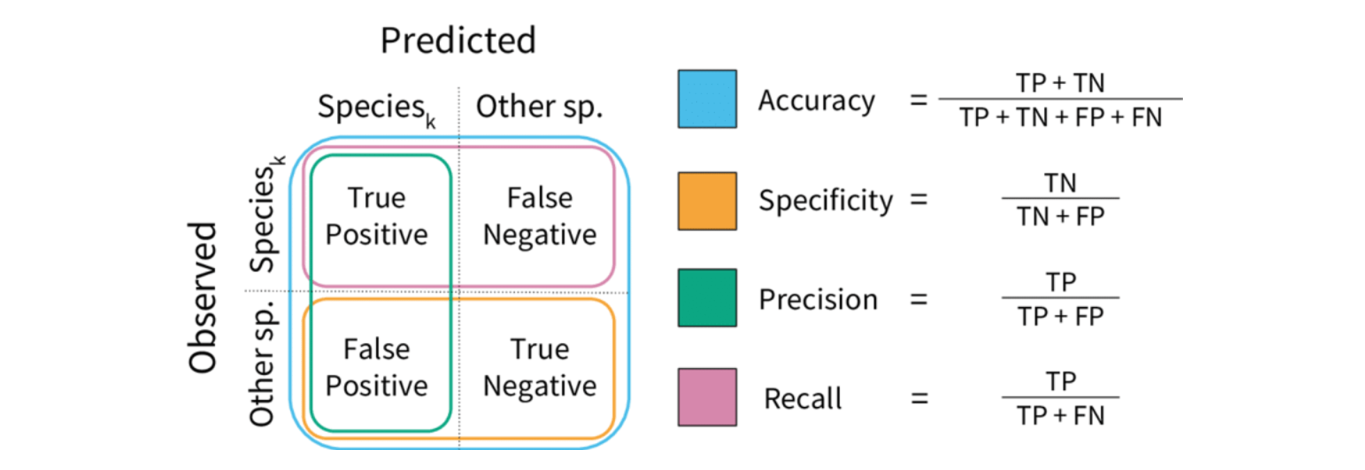

In [ ]:
mo.image(src="assets/precision-v-recall.png", width=800).center()

$$
\text{F1 Score} = 2 \times \frac{\text{Recall}\times\text{Precision}}{\text{Recall} + \text{Precision}} = \frac{2\text{TP}}{\text{2TP + FN + FP}}
$$

Imagine a model that just predicts `at-risk` for every single student, no matter what. Plain accuracy would reward that model with a score of 85.9%, since it happens to guess right most of the time. But its recall on `fit` is 0%, and its recall on `unhealthy` is 0%. Balanced accuracy averages those three recall values: (0 + 100 + 0)/3, which comes out to roughly 33.3%. That's barely better than random guessing across three classes. This tells you the metric will punish any model that leans on the majority class as a shortcut.

**Exercise 1**: Reimplement `balanced_accuracy` based on the description given above.

In [ ]:
def flip_minority(n):
    if n == 0:
        return n
    return n - 1 if n == 2 else n + 1

def accuracy(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    correct_predictions = np.sum(y_true == y_pred)
    total_predictions = len(y_true)

    if total_predictions == 0:
        return 0.0
    return correct_predictions / total_predictions

In [ ]:
def class_recall(y_true, y_pred, k) -> float:
    # True Positives (Actually K, Predicted K)
    TP = np.sum((y_true == k) & (y_pred == k))

    # False Negatives (Actually K, Predicted !K)
    FN = np.sum((y_true == k) & (y_pred != k))

    return TP / (TP + FN) if (TP + FN) > 0 else 0.0

def balanced_accuracy(y_true, y_pred) -> float:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    classes = np.unique(y_true)
    recall = 0

    # Add your code here ...

    return 0.0

y_true = pd.Series(train_data["health_condition"].astype("category").cat.codes, name="health_condition")

y_pred = y_true.map(flip_minority)

print(f"Accuracy (Ours): {accuracy(y_true, y_pred) * 100:.2f}%")
print(f"Accuracy (Scikit-learn's): {accuracy_score(y_true, y_pred) * 100:.2f}%\n")
print(f"Balanced Accuracy (Ours): {balanced_accuracy(y_true, y_pred) * 100:.2f}%")
print(f"Balanced Accuracy (Scikit-learn's): {balanced_accuracy_score(y_true, y_pred) * 100:.2f}%")

In [ ]:
def plot_distributions_by_target(
    df:pd.DataFrame,
    target:str,
    nfeats:list[str],
    ncols:int,
    figsize=(15, 15)
) -> plt.Axes:

    nrows = -(-len(nfeats) // ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
    for i, feat in enumerate(nfeats):
        row, col = i // ncols, i % ncols
        ax = axes[row, col] if nrows > 1 else axes[col]
        ax.set_title(f"{target} vs {feat}")
        sns.boxplot(df, x=target, y=feat, hue=target, ax=ax)

    if len(nfeats) % ncols != 0:
        for j in range(len(nfeats) % ncols, ncols):
            axes[-1, j].axis("off")

    fig.tight_layout()
    fig.suptitle("Distributions by Target", y=1.05, size=20)
    return plt.gca()

plot_distributions_by_target(train_data.drop("id", axis=1), "health_condition", num_cols, 3)

**Observations**:

**Strong, clearly ordered relationships**
- `sleep_duration`: Very clean separation. The boxes barely overlap.
- `step_count`: Fit stands well apart from unhealthy/at-risk, which overlap heavily with each other.
- `exercise_duration`: Similar pattern to `step_count`. Fit is clearly higher and tighter, while unhealthy and at-risk overlap substantially.
- `bmi`: Monotonic and ordered. Though the boxes overlap quite a bit more than `sleep_duration`, it is still directionally informative.

**Weak or negligible relationships**
- `heart_rate`: The three boxes are nearly identical.
- `calorie_expenditure`: Medians and IQRs are very close across all three classes with heavy overlap.
- `water_intake`: Essentially identical distributions across all three groups.

**Fit** is the most distinct class, especially on `step_count` and `exercise_duration`. It's clearly separated from the two. **Unhealthy** vs **At-Risk** is the harder distinction since for several features (`step_count`, `calorie_expenditure`, `heart_rate`) their boxes overlap almost completely. This suggests that the model may struggle most to distinguish these two classes from each other.

### Target Correlation

In [ ]:
def encode_ordinal_data(data, ord_map):
    encode_ordinal = lambda feat: dict(zip(ord_map[feat], np.arange(len(ord_map[feat]))))
    copy = data.copy()
    for feat in ord_map.keys():
        copy[feat] = copy[feat].map(encode_ordinal(feat))
    return copy

def plot_target_correlation(
    data: pd.DataFrame,
    target: str,
    target_map:dict,
    fmt=".2f",
    cmap="Greens",
    figsize=(15, 8)
) -> plt.Axes:
    copy = data.select_dtypes(include="number")
    copy[target] = data[target].map(target_map)

    fig = plt.figure(figsize=figsize, constrained_layout=True)
    gs = fig.add_gridspec(1, 3)

    corr_hm_ax = fig.add_subplot(gs[0, :2])
    corr_target_ax = fig.add_subplot(gs[0, 2])
    mask = np.tril(copy.corr())

    corr_hm_ax.set_title("Pearson Correlation Matrix", size=15)
    corr_target_ax.set_title(f"Correlation to Target ({target})", size=15)

    sns.heatmap(copy.corr(), mask=mask, annot=True, fmt=fmt,
                cmap=cmap, ax=corr_hm_ax, cbar=False, annot_kws={"size": 10})

    sns.heatmap(copy.corr()[target].sort_values(ascending=False).to_frame(),
                annot=True, fmt=fmt, cmap=cmap, ax=corr_target_ax)

    corr_target_ax.set_yticklabels(corr_target_ax.get_yticklabels(), rotation=0)
    corr_hm_ax.set_xticklabels(corr_hm_ax.get_xticklabels(), rotation=45)

    fig.suptitle("Target Correlation", y=1.07, size=18)
    return plt.gca()

_copy = encode_ordinal_data(train_data.drop("id", axis=1), ord_map)

plot_target_correlation(_copy, "health_condition", {"unhealthy": 0, "at-risk": 1, "fit": 2})

**Observations**: Confirms some previous observations from viewing the feature distributions from the target.

- `sleep_duration` and `bmi` show strong linear signals. This is consistent with the clean, monotonic separation in the box plots.
- `heart_rate` and `water_intake` are essentially uncorrelated, matching the fully-overlapping boxplots.
- `step_count` and `exercise_duration` show up as a weak-ish signal here, which *understates* their real value given what the boxplots showed (strong for separating "fit", weak for the other two classes).

### Missing Data

In [ ]:
def plot_missing_proportion(df:pd.DataFrame, subset:str, figsize=(15, 8)) -> None:
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    total = df.shape[0]
    missing = df.isna().sum().sum()

    axes[0].pie(x=[total, missing], labels=["Overall", "Missing"], autopct="%1.1f%%")
    axes[0].set_title("Overall vs Missing Values")

    missing_pct = df.drop("id", axis=1).isna().mean() * 100
    present_pct = 100 - missing_pct 

    p = axes[1].barh(missing_pct.index, missing_pct, color="#fc8d62", label="Missing") #66c2a5
    axes[1].barh(missing_pct.index, present_pct, left=missing_pct, color="#66c2a5",label="Present") #fc8d62
    axes[1].set_title("Missing values per feature (%)")
    axes[1].set_xlabel("Percentage (%)")
    axes[1].set_xlim(0, 100)
    axes[1].legend(loc="lower right")
    axes[1].bar_label(p, label_type="edge", fmt="%1.1f%%", padding=4)

    fig.suptitle(f"Missing Data ({subset})", size=18)
    fig.tight_layout()

    return plt.gca()

In [ ]:
plot_missing_proportion(train_data, "Train")

In [ ]:
plot_missing_proportion(test_data, "Test")

**Observations**:
- Nearly half of the dataset consists of missing values with about **39.4%** missing and **60.6%** overall.
- Missingness is low in absolute terms, but scattered across nearly every feature.
- There's a clear split between subjective/self-reported fields and objective/logged fields.

Looking at which features have high missing rates:

- `stress_level`, `sleep_duration`, `sleep_quality`, `water_intake`, `calorie_expenditure`.

versus the lowest:

- `diet_type`, `exercise_duration`, `bmi`, `step_count`, `heart_rate`.

The high-missing group tends to be things people self-report or that require wearable/consistent tracking, while the low-missing group looks more like fields that are either directly measured or mandatory intake questions.

## Feature Distributions

### Numerical Features

In [ ]:
def plot_num_feat_distribution(
    train_data:pd.DataFrame, 
    test_data:pd.DataFrame, 
    ncols:int,
    bins=30,
    figsize=(15, 10)
) -> None:
    train_num = train_data.select_dtypes(include="number")
    test_num = test_data.select_dtypes(include="number") 

    nfeats = train_num.columns.tolist()[1:]
    nrows = -(-len(nfeats) // ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)

    for i, feat in enumerate(nfeats):
        row, col = i // ncols, i % ncols
        ax = axes[row, col] if nrows > 1 else axes[col]
        sns.histplot(data=train_num, x=feat, bins=bins, kde=True, ax=ax, label="Train")
        sns.histplot(data=test_num, x=feat, bins=bins, kde=True, ax=ax, label="Test")

    if len(nfeats) % ncols != 0: 
        for i in range(len(nfeats) % ncols, ncols):
            axes[-1, i].axis('off')

    axes[0, 0].legend()
    fig.tight_layout()
    fig.suptitle("Numerical Feature Distibutions (Train & Test)", y=1.04, size=17)
    return plt.gca()

plot_num_feat_distribution(train_data, test_data, 2, bins=25)

### Categorical Features

In [ ]:
def plot_cat_feat_distribution(
    train_data:pd.DataFrame,
    test_data:pd.DataFrame,
    target:str, 
    cat_cols:list,
    stat:str="proportion",
    figsize=(15, 10)
) -> None:

    if target in cat_cols:
        cat_cols.remove(target)

    train_cat = train_data[cat_cols]
    test_cat = test_data[cat_cols]

    fig, axes = plt.subplots(nrows=len(cat_cols), ncols=2, figsize=figsize)

    for i, col in enumerate(cat_cols):
        c0 = sns.countplot(train_data, x=col, hue=col, stat=stat, ax=axes[i, 0])
        c1 = sns.countplot(test_data, x=col, hue=col, stat=stat, ax=axes[i, 1])

        for container in c0.containers:
            axes[i, 0].bar_label(container, fmt="%.3f")
        for container in c1.containers:
            axes[i, 1].bar_label(container, fmt="%.3f")

        axes[i, 0].set_title("Train")
        axes[i, 1].set_title("Test")

        axes[i, 0].get_legend().set_visible(False)
        axes[i, 1].get_legend().set_visible(False)

    fig.tight_layout()
    fig.suptitle("Categorical Feature Distributions (Train & Test)", y=1.04, size=16)

    return plt.gca()

plot_cat_feat_distribution(train_data, test_data, "health_condition", cat_cols)

### Ordinal Features

In [ ]:
def create_prop_map(df:pd.DataFrame, ord_mapping:dict[str, list[str]]):
    cnt_map = {}

    for col in list(ord_mapping.keys()):
        cnt_map[col] = dict.fromkeys(ord_mapping[col], 0)
        cnt_map[col]["nan"] = 0

        for cat in cnt_map[col]:
            if cat == "nan":
                cnt_map[col][cat] = df[col].isna().sum()
            else:
                cnt_map[col][cat] = df[df[col] == cat].shape[0]
            cnt_map[col][cat] *= 1.0
            cnt_map[col][cat] /= df.shape[0]

    return cnt_map

def plot_ordinal_feature_distribution(
    train_data:pd.DataFrame, 
    test_data:pd.DataFrame, 
    ord_mapping:dict[str, list[str]], 
    figsize=(15, 10)
) -> None:

    train_cnts = create_prop_map(train_data, ord_mapping)
    test_cnts = create_prop_map(test_data, ord_mapping)


    fig, axes = plt.subplots(nrows=len(ord_cols), ncols=2, figsize=figsize)
    fig.tight_layout()

    axes[0, 0].set_title("Train")
    axes[0, 1].set_title("Test")

    for i, col in enumerate(list(ord_mapping.keys())):
        set2 = plt.cm.Set2.colors
        colors = [set2[j] if cat != "nan" else "#bdc3c7" for j, cat in enumerate(train_cnts[col].keys())]

        b0 = axes[i, 0].bar(x=list(train_cnts[col].keys()), height=list(train_cnts[col].values()), color=colors)
        b1 = axes[i, 1].bar(x=list(test_cnts[col].keys()), height=list(test_cnts[col].values()), color=colors)
        axes[i, 0].bar_label(b0, labels=[f"{v:.3f}" for v in train_cnts[col].values()])
        axes[i, 1].bar_label(b1, labels=[f"{v:.3f}" for v in test_cnts[col].values()])

        axes[i, 0].set_xlabel(f"{col}")
        axes[i, 1].set_xlabel(f"{col}")

        axes[i, 0].set_ylabel("Proportion")
        axes[i, 1].set_ylabel("Proportion")

    fig.tight_layout()
    fig.suptitle("Ordinal Feature Distributions (Train & Test)", y=1.04, size=16)

    return plt.gca()

ord_mapping = dict.fromkeys(ord_cols, [])

ord_mapping["sleep_quality"] = ["poor", "average", "good"]
ord_mapping["physical_activity_level"] = ["sedentary", "moderate", "active"]
ord_mapping["stress_level"] = ["low", "medium", "high"]

plot_ordinal_feature_distribution(train_data, test_data, ord_mapping)

**Observations**: No visible distribution drift between train and test data.

# 2. Cross-validation

## `train_test_split` pit falls

Using a single train-test split (such as an 80/20 split) is inadequate for validating machine learning models, even when scores appear stable across random seeds. Let's see why.

The cell below trains a `DecisionTreeClassifier` on different seed configurations of `train_test_split`.

In [ ]:
_trans = ColumnTransformer(
    transformers=[
        # Ordinal Pipeline
        ('ord', Pipeline([
            ('encoder', OrdinalEncoder(
                    categories=ord_categories,
                    handle_unknown="use_encoded_value",
                    unknown_value=-1
                )
            )
        ]), ord_cols),

        # Categorical Pipeline 
        ('cat', Pipeline([
            ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_cols)
    ],
    remainder="passthrough"
) 

def _display_stats(scores: list) -> None:
    arr = np.asarray(scores)
    print(f"Mean:     {arr.mean():.5f}")
    print(f"Std Dev:  {arr.std():.5f}")
    print(f"Variance: {arr.var():.6e}")

def train_w_seeds(
    train_data: pd.DataFrame,
    target: str,
    tree_model: BaseEstimator,
    trans: ColumnTransformer,
    seeds: list, 
    config_seed: int = 42
):
    scores = []
    pp = Preprocessor(train_data, target=target)

    for i, seed in enumerate(seeds):
        print(f"Iteration {i + 1} (Seed: {seed}): ")
        print("-" * 30)

        pp.split_data(test_size=0.2, stratify=False, random_state=seed)
        pp.fit(trans)
        pp.transform()
        pp.encode_target(inplace=True, as_series=True)

        X, y = pp.get_split()

        tree_model.fit(X["train"], y["train"])
        y_pred = tree_model.predict(X["valid"])
        score = balanced_accuracy(y["valid"], y_pred)
        scores.append(score)

        print(f" - Balanced Accuracy: {score:.5f}\n")

    _display_stats(scores)

train_w_seeds(
    train_data, 
    "health_condition", 
    DecisionTreeClassifier(min_samples_leaf=1, random_state=CONFIG["SEED"]),
    _trans,
    [42, 123, 456, 1337],
    CONFIG["SEED"]
)

You may notice that the scores are actually quite **stable** across different seeds — the variance is small. With 50,000 rows, random splits tend to produce similar class distributions by the law of large numbers. But stable scores do **not** mean a single split is trustworthy. Here are the real pitfalls:

1. **No guarantee of representative class distribution**

Without stratification, random splits can produce validation sets where minority classes (`fit` at ~5.8%, `unhealthy` at ~8.4%) are under- or over-represented. With smaller datasets, this effect is even more pronounced. Even with large datasets, you have no control over whether the split reflects the true population proportions — you are relying on chance.

2. **No statistical confidence interval**

A single split gives you one score with no measure of uncertainty. You cannot say whether a balanced accuracy of 85% is genuinely different from 83% — the difference could easily be noise. Cross-validation provides K independent estimates, letting you compute a mean and standard deviation that quantify how reliable the score actually is.

3. **A single score conflates luck with quality**

If your validation set happens to contain easier or harder examples than the population, the score will be biased in that direction. With K-fold CV, each sample is used for validation exactly once, so lucky and unlucky folds average out.

4. **Irreproducible model selection**

If you use a single split to pick between two similar models, the choice depends on which specific samples landed in validation. A different seed could reverse the decision. Cross-validation reduces this risk because every model is evaluated on the same folds.

In short: even when scores look stable, a single split lacks the statistical rigor needed to trust your evaluation.

In [ ]:
def target_distribution_by_seed(
    data: pd.DataFrame, 
    target: str, 
    seeds: list[int]
) -> None:
    pp = Preprocessor(data, target=target, drop_id=True)
    classes = pp._target.unique()

    print(f"Target Proportions Across {len(seeds)} Random Single-Split Seeds")
    print("-" * 54)

    for seed in seeds:
        pp.split_data(test_size=0.2, stratify=False, random_state=seed)
        X, y = pp.get_split()

        y_train, y_val = y["train"], y["valid"]
        train_size, val_size = len(y_train), len(y_val)

        print(f"Seed {seed:<5} | Train (n={train_size}) vs Valid (n={val_size}):")

        for cls in classes:
            train_prop = (np.sum(y_train == cls) / train_size) * 100
            val_prop = (np.sum(y_val == cls) / val_size) * 100
            print(f"  - {cls:<10} -> Train: {train_prop:.2f}% | Valid: {val_prop:.2f}%")
        print()

In [ ]:
target_distribution_by_seed(
    train_data,
    "health_condition",
    [42, 123, 456, 1337]
)

## ⭐ **K-Fold Cross-validation**: Regular vs Stratified

K-fold CV is a statistical validation technique used to evaluate how well a machine learning model generalizes to unseen data.

Instead of relying on a single train/validation split, the training dataset is randomly partitioned into $K$ equal-sized subsets called **folds**.

```
Entire Dataset (100%)

 ┌──────────┬──────────┬──────────┬──────────┬──────────┐
 │  Fold 1  │  Fold 2  │  Fold 3  │  Fold 4  │  Fold 5  │
 └──────────┴──────────┴──────────┴──────────┴──────────┘

Iteration 1: [ Validate ] [   Train  ] [   Train  ] [   Train  ] [   Train  ]
Iteration 2: [   Train  ] [ Validate ] [   Train  ] [   Train  ] [   Train  ]
Iteration 3: [   Train  ] [   Train  ] [ Validate ] [   Train  ] [   Train  ]

...
```
**Exercise 2**: View the target distribution of each fold for `K-Fold` and `StratifiedKFold` with the following parameters:

- `n_splits` : 5
- `shuffle` : True
- `random_state` : A random seed either from the config or your own (Make sure to use on both CV methods for consistency of results)

<details>
    <summary><b>Hint</b></summary>
    <code>KFold</code>:<a>https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html</a>
    <br>
    <code>StratifiedKFold</code>:<a>https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html</a>
</details>

In [ ]:
def target_distribution_by_fold(
    data: pd.DataFrame, 
    target: str, 
    cv_method, 
    seed: int,
) -> None:
    pp = Preprocessor(data, target=target, drop_id=True)
    X = pp.get_data() if target is None else pp._data
    y = pp._target

    classes = y.unique()
    n_splits = getattr(cv_method, "n_splits", 5)
    class_props = {cls: [] for cls in classes}

    print(f"Target Distribution Across {n_splits} Folds:")
    print("-" * 67)
    for i, (_, valid_idx) in enumerate(cv_method.split(X, y)):
        y_valid = y.iloc[valid_idx]
        valid_size = len(y_valid)

        print(f"Fold {i + 1} (N: {len(y_valid)}): [", end="")

        for j, cls in enumerate(classes):
            end = ", " if j + 1 != len(classes) else ""
            prop = (np.sum(y_valid == cls) / valid_size) * 100
            class_props[cls].append(prop)
            print(f"{cls}: {prop:.2f}%", end=end)

        print("]")

    print("\nCross-Fold Validation Class Stability:")
    for cls, props in class_props.items():
        arr = np.asarray(props)
        print(f" - {cls:<10} | Mean: {arr.mean():.2f}% | Var: {arr.var():.6f}% | Std Dev. {arr.std():.4f}% |")

In [ ]:
# View target distributions for regular K-Fold
target_distribution_by_fold(
    train_data, 
    "health_condition",
    seed=CONFIG["SEED"],
    cv_method= # Add KFold CV here ...
)

In [ ]:
# View target distributions for stratified K-Fold
target_distribution_by_fold(
    data=train_data,
    target="health_condition",
    seed=CONFIG["SEED"],
    cv_method= # Add StratifiedKFold CV here ...
)

For **regular K-Fold**, class proportions fluctuate slightly across folds. K-Fold partitions the data into $K$ equal-sized chunks using a random permutation only — it never looks at the target. Each fold is therefore a *simple random sample* of the full dataset, so by ordinary sampling variation the shares of `fit` / `at-risk` / `unhealthy` drift a little around their population rates (here roughly 5.8% / 85.9% / 8.4%). Notice the cross-fold variance is not zero, e.g. `at-risk` ranges from 85.73% to 85.95%. This is expected: it is the same reason a coin flipped ten times rarely lands exactly 5-5.

For **StratifiedKFold**, the proportions are essentially identical across every fold (variance = 0.0000%). That is the whole point: it splits the data *within* each class first, then distributes each class's rows across the folds proportionally. Every fold therefore reproduces the overall target distribution as closely as the row counts allow, e.g. exactly 8.36% `unhealthy` in all five folds.

**Why this matters**: validation folds that mirror the population distribution yield more stable, representative estimates of model performance. With an imbalanced target, a lucky or unlucky regular K-Fold split could leave a fold with too few `fit` or `unhealthy` samples to evaluate fairly — and each fold's score would inherit that random wobble. Stratified K-Fold removes this source of variance, so any performance differences you observe between models are more likely to be real rather than artifacts of the split.

# 3. Modelling

We now have everything we need to start training models: a way to measure performance that matches the competition metric (`balanced_accuracy`, Exercise 1) and a validation strategy that respects the class imbalance (`StratifiedKFold`, Exercise 2).

Before building anything clever, we establish a **baseline** — the simplest possible predictions — to set a floor that every real model must beat.

**Exercise 3**: Score two baselines under `StratifiedKFold` with the `balanced_accuracy` you implemented in Exercise 1:

1. **Majority-class baseline** — a model that always predicts the most common class (`at-risk`). Based on the Problem Framing discussion, what balanced accuracy do you expect it to get?
2. **Vanilla `LogisticRegression`** — no tuning, no class weighting.

Use the same `StratifiedKFold(n_splits=5, shuffle=True, random_state=CONFIG["SEED"])` from Exercise 2 and the notebook's `CrossValidator`.

<details>
    <summary><b>Hint</b></summary>
    <code>DummyClassifier(strategy="most_frequent")</code>is the go-to majority baseline.
</details>

In [ ]:
def view_confusion_matrices(
    cv: CrossValidator,
    X: dict,
    y: dict,
    ncols: int,
    figsize: tuple[int, int]=(10, 10),
    labels=None,
):

    models = cv.get_models()
    nrows = -(-len(models) // ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
    preds = cv.predict(X["valid"], y_train=y["train"])

    if labels is None:
        labels = y["valid"].unique()

    for i, (name, y_pred) in enumerate(preds.items()):
        row, col = i // ncols, i % ncols
        ax = axes[row, col] if nrows > 1 else axes[col]

        cm = confusion_matrix(y["valid"], y_pred, normalize="true")
        sns.heatmap(
            cm, cmap="Greens", annot=True, fmt=".2f", 
            ax=ax, xticklabels=labels, yticklabels=labels, 
            annot_kws={"size": 10}, square=True, cbar=False
        )
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
        ax.set_title(name)

    if len(models) % ncols != 0:
        if nrows > 1:
            for j in range(len(models) % ncols, ncols):
                axes[-1, j].axis("off")
        else:
            for j in range(len(models) % ncols, ncols):
                axes[j].axis("off")
    fig.tight_layout()
    return plt.gca()

In [ ]:
_trans = ColumnTransformer(
    transformers=[
        # Numerical Pipeline
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy="median", add_indicator=True)),
            ('scaler', RobustScaler())
        ]), num_cols),

        # Ordinal Pipeline
        ('ord', Pipeline([
            ('imputer', SimpleImputer(strategy="most_frequent")),
            ('encoder', OrdinalEncoder(
                    categories=ord_categories,
                    handle_unknown="use_encoded_value",
                    unknown_value=-1
                )
            )
        ]), ord_cols),

        # Categorical Pipeline 
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy="most_frequent")),
            ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_cols)
    ]
)

base_pp = Preprocessor(train_data, "health_condition")
base_pp.split_data(random_state=CONFIG["SEED"])
base_pp.fit(_trans)
base_pp.transform()
base_pp.encode_target(inplace=True, as_series=True)
X_b, y_b = base_pp.get_split()

base_models = [
    # ("Model Name", BaseEstimator)
    # Majority Class ...
    # Logistic Regression ...
    ("Constrained Decision Tree", DecisionTreeClassifier(max_depth=8, min_samples_leaf=500, random_state=CONFIG["SEED"]))
]

base_cv_1 = CrossValidator(
    models=base_models,
    metric_fns=[("balanced_accuracy", balanced_accuracy)],
    verbose=True,
    cv_method= # Add CV method here ...
)

base_cv_1.fit(X_b["train"], y_b["train"])

view_confusion_matrices(
    base_cv_1, X_b, y_b, 3, labels=base_pp.get_classes(), figsize=(15, 15)
)

The **majority-class baseline** scores around 33.3% balanced accuracy — exactly the 1/3 you would expect when the model only ever gets `at-risk` right. Its plain accuracy would be ~86%, which is precisely why the competition metric punishes it. The **vanilla `LogisticRegression`** should clear that floor comfortably, even without any class weighting or tuning.

Everything from here on is measured against these two numbers: any serious model must beat the `LogisticRegression` baseline.

Although we now have a reliable cross-validation strategy, we still have to address the class imbalance of our target. This is important because models naturally develop a bias towards the majority class when trained on imbalance datasets.

## Class Weights

How do we ensure that our model treats each class the same during training despite the imbalance? We give each class a penalty weight that matches the reverse of its sample count i.e., **inverse-frequency class weights**:

$$
W_k = \frac{N}{K \times N_k}
$$

where,

$$
N \rightarrow \text{Total number of samples}
$$

$$
K \rightarrow \text{Total number of classes}
$$

$$
N_k \rightarrow \text{Samples in class } k
$$

The cell below shows how you would calculate for class weights using `NumPy` and how they are applied onto model predictions.

In [ ]:
def class_weights(y_true) -> dict:
    classes, N_k = np.unique(y_true, return_counts=True)
    N = len(y_true)
    K = len(classes)
    return dict(zip(classes, N / (K * N_k)))

weights = class_weights(y_true)
sample_weights = np.array([weights[y] for y in y_true])

print(sample_weights)

mo.md(
    f"""
    Weights:
    {mo.as_html(weights)}
    """
)

**Exercise 4**: Run a new cross-validation similar to that of exercise 3, except now enable the use of sample weights via the `sample_weight_fn` parameter of the `CrossValidator` class.

<details>
    <summary><b>Hint</b></summary>
    <code>functools.partial</code>:<a>https://www.learnpython.org/en/Partial_functions</a>
    <br>
    <code>compute_sample_weight</code>:<a>https://scikit-learn.org/stable/modules/generated/sklearn.utils.class_weight.compute_sample_weight.html</a>
</details>

In [ ]:
base_cv_2 = CrossValidator(
    models=base_models,
    metric_fns=[("balanced_accuracy", balanced_accuracy)],
    cv_method=StratifiedKFold(n_splits=5, shuffle=True, random_state=CONFIG["SEED"]),
    sample_weight_fn= # Add sample weight function here ...
    verbose=True,
)

base_cv_2.fit(X_b["train"], y_b["train"])
view_confusion_matrices(
    base_cv_2, X_b, y_b, 3, labels=base_pp.get_classes(), figsize=(15, 15)
)

In [ ]:
def aggregate_predictions(cv:CrossValidator, X:dict, y:dict):
    results = {}
    preds = cv.predict(X["valid"], y_train=y["train"])
    metric_fns = cv.get_metric_fns()
    for model, pred in preds.items():
        results [model] = {}
        for item in metric_fns:
            name, fn = item
            results[model][name] = fn(y["valid"], pred)
    return pd.DataFrame(results).T, preds

In [ ]:
_df, _ = aggregate_predictions(base_cv_2, X_b, y_b)
_df.sort_values(by="balanced_accuracy", ascending=False)

The **sample weights** visibly changed the story. Compare the two baseline runs side by side:

| Model | Balanced accuracy (unweighted) | Balanced accuracy (weighted) |
|---|---:|---:|
| `Majority Class` | 33.3% | 33.3% |
| `LogisticRegression` | 80.97% | 87.33% |
| `Constrained Decision Tree` | 84.75% | 90.07% |

The weights alter *what the model optimizes*, and the effect is dramatic:

1. **`LogisticRegression`** improves by **~6.4 points**. Unweighted, it "wasted" capacity trying to be perfect on the ~86% majority class; forcing it to care about every class equally translates directly into balanced accuracy.
2. **`Constrained Decision Tree`** improves by **~5.3 points**, reaching **90.07%** — the best score so far.

This is the trade-off from the Problem Framing discussion made concrete: weighted training **trades plain accuracy for balanced accuracy** — precisely what the competition metric rewards. Every serious model from here on is trained with sample weights.

**Exercise 5**: The `Constrained Decision Tree` above used `max_depth=8, min_samples_leaf=500` — but how would we know that is a good choice, and why constrain the tree at all?

A tree's **capacity** controls how complex a decision boundary it can learn. Too little capacity *underfits* (high bias); too much capacity memorizes the training set and fails to generalize (high variance) — the exact pitfall from the `train_test_split` section.

Sweep the capacity and watch what happens to **training vs. validation** balanced accuracy:

1. Vary `max_depth` while holding `min_samples_leaf=500`.
2. Vary `min_samples_leaf` while holding `max_depth=8`.

Complete the `_evaluate` inner function by using the `balanced_accuracy` function that you made.

Use the same transformed data (`X_b`, `y_b`) and the same sample weights as `base_cv_2`.

<details>
    <summary><b>Hint</b></summary>
    The two curves expose the bias-variance trade-off: the <b>training</b> curve keeps climbing with capacity, while the <b>validation</b> curve peaks and then falls. The best capacity is where validation peaks — not where training looks best.
</details>

In [ ]:
def sweep_capacity(
    X: dict,
    y: dict,
    depths: list[int],
    min_leaves: list[int],
    fixed_max_depth: int = 8,
    fixed_min_samples_leaf: int = 500,
    seed: int = 42,
) -> tuple[dict, dict]:

    weights = compute_sample_weight("balanced", y["train"])

    def _evaluate(clf) -> dict[str, float]:
        # Add your code here ...
        clf.fit(X["train"], y["train"], sample_weight= ...)
        return {
            "train": ...,
            "valid": ...
        }

    by_depth = {
        d: _evaluate(
            DecisionTreeClassifier(
                max_depth=d,
                min_samples_leaf=fixed_min_samples_leaf,
                random_state=seed,
            )
        )
        for d in depths
    }
    by_min_leaf = {
        m: _evaluate(
            DecisionTreeClassifier(
                max_depth=fixed_max_depth,
                min_samples_leaf=m,
                random_state=seed,
            )
        )
        for m in min_leaves
    }
    return by_depth, by_min_leaf

depths = [2, 3, 4, 6, 8, 10, 14, 20, 30]
min_leaves = [10, 50, 100, 250, 500, 1000, 2000]

by_depth, by_min_leaf = sweep_capacity(
    X_b, y_b, depths, min_leaves, seed=CONFIG["SEED"]
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, xs, curves, xlabel, chosen in [
    (axes[0], depths, by_depth, "max_depth", 8),
    (axes[1], min_leaves, by_min_leaf, "min_samples_leaf", 500),
]:
    ax.plot(xs, [curves[x]["train"] for x in xs], "o-", color="tab:blue", label="train")
    ax.plot(xs, [curves[x]["valid"] for x in xs], "o-", color="tab:green", label="valid")
    ax.axvline(chosen, color="tab:red", ls="--", lw=1.2, label=f"chosen: {chosen}")
    ax.set_xlabel(xlabel)
    ax.set_xticks(xs)
    ax.grid(alpha=0.3)
axes[0].set_ylabel("balanced accuracy")
axes[0].legend()
fig.tight_layout()
plt.gca()

### The importance of experimentation

Step back and look at how the Modelling section progressed. Every step changed **exactly one thing** while keeping the measurement strategy fixed — the same `StratifiedKFold`, the same `balanced_accuracy`, and (from Exercise 4 on) the same sample weights:

| Stage | The one thing changed | Best balanced accuracy |
|---|---|---:|
| 1. Baselines (Exercise 3) | — | 84.75% (`Constrained Tree`) |
| 2. Sample weights (Exercise 4) | loss weighting | 90.07% (`Constrained Tree`) |
| 3. Capacity sweep (Exercise 5) | model capacity | *why* the tree is constrained |
| 4. Model comparison (next) | model family | ? |

Because the folds and the metric never changed, each improvement is **attributable to the single change** — not to the luck of a different split.

Experimentation also means embracing **negative results**. Not every change pays off (feature engineering is next, and it will not move the needle), but a *controlled* negative result still teaches you something: it rules out a hypothesis and stops you from chasing a dead end. The discipline is always the same — change one variable, hold everything else fixed, and measure with the same metric and folds.

## Model Comparison

We have a strong baseline (~90% balanced accuracy). The next step is **model comparison**: train several *different* model families under **identical conditions** and let the validation strategy decide which one is best.

### What it is

The `CrossValidator` is built exactly for this. A single `_trans` preprocessing pipeline, a single `StratifiedKFold`, a single metric list, and a single `sample_weight_fn` are shared across every candidate model — the only thing that varies is the **model itself**. Because all candidates see the same folds, the same preprocessing, and the same metric, the out-of-fold scores and confusion matrices are directly comparable.

### Why we do it

No single algorithm wins on every dataset (the "no free lunch" theorem). Gradient boosted trees work very differently from a linear model:

- **`LogisticRegression`** learns a single linear decision boundary — it cannot capture nonlinear interactions on its own.
- **`XGBoost`**, **`LightGBM`**, and **`HistGradientBoost`** build an additive ensemble of shallow trees, so they model nonlinear interactions and missing values natively, and they are regularized — meaning they can use far more capacity than a single tree without the overfitting we just saw in Exercise 5.
- **`LightGBM`** grows trees *leaf-wise* (XGBoost grows level-wise) and uses histogram-based binning, which is typically faster and often marginally more accurate on larger data.

The gap between the constrained tree (~90%) and the boosted models quantifies how much of the signal in the data is *nonlinear* — a ceiling the linear model could never reach, no matter how much you tuned it.

**Exercise 6**: Now that we understand preprocessing, stratified K-Fold, and sample weights, let's put it all together. Set up a full cross-validation pipeline with the three gradient boosting models (`HistGradientBoostingClassifier`, `XGBClassifier`, `LGBMClassifier`) and run it on the training data.

In [ ]:
_trans = ColumnTransformer(
    transformers=[
        # Ordinal Pipeline
        ('ord', Pipeline([
            ('encoder', OrdinalEncoder(
                    categories=ord_categories,
                    handle_unknown="use_encoded_value",
                    unknown_value=-1
                )
            )
        ]), ord_cols),

        # Categorical Pipeline 
        ('cat', Pipeline([
            ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_cols)
    ],
    remainder="passthrough",
)

pp_1 = Preprocessor(train_data, "health_condition")

# Add preprocessing steps here ...

X_1, y_1 = pp_1.get_split()

models_1 = [
    ("HistGradientBoost", HistGradientBoostingClassifier(random_state=CONFIG["SEED"])),
    ("XGBoost", XGBClassifier(device="cuda", random_state=CONFIG["SEED"])),
    ("LightGBM", LGBMClassifier(verbose=0, device="gpu", random_state=CONFIG["SEED"]))
]

cv_1 = CrossValidator(
    models=models_1,
    metric_fns=metric_fns,
    cv_method= ...,
    sample_weight_fn= ...,
    pi_kwargs = {'scoring':'balanced_accuracy', 'random_state': CONFIG["SEED"], 'n_jobs': 2, 'n_repeats': 3},
)

cv_1.fit(X_1["train"], y_1["train"])
view_confusion_matrices(cv_1, X_1, y_1, ncols=3, labels=pp_1.get_classes())

KeyError: 'train'

In [ ]:
cv_1.get_oof_metrics_df().sort_values(by="balanced_accuracy", ascending=False)

In [ ]:
_df, _ = aggregate_predictions(cv_1, X_1, y_1)
_df.sort_values(by="balanced_accuracy", ascending=False)

All three boosted models clear the `Constrained Decision Tree` (90.07%) by a wide margin, landing at **~95% balanced accuracy**:

| Model | Balanced accuracy | Macro F1 |
|---|---:|---:|
| `LightGBM` | 94.98% | 86.41% |
| `XGBoost` | 94.96% | 86.82% |
| `HistGradientBoost` | 94.94% | 86.33% |

The three are essentially tied on balanced accuracy — `LightGBM` a hair ahead — with `XGBoost` slightly stronger on macro F1. The ~5-point jump over the best weighted baseline is the value of a regularized nonlinear ensemble over a single tree.

The permutation-importance plot below tells us *which* features drive these predictions.

## Permutation Importance

**Permutation importance** measures how much a model's performance drops when a
single feature's values are randomly shuffled. If shuffling a feature causes a
large drop in accuracy, that feature is important. If performance barely changes,
the model doesn't rely on it.

### How it works

1. Train a model and measure its baseline score on a validation set.
2. For each feature, randomly shuffle its values (breaking the relationship
   between the feature and the target).
3. Re-score the model. The difference from the baseline is the feature's
   importance.

$$
\text{Importance}_j = \text{Score}_{\text{baseline}} - \text{Score}_{\text{shuffled}_j}
$$

### Why use it

- **Model-agnostic**: works with any model, not just tree-based.
- **Intuitive**: directly answers *"how much do I lose without this feature?"*
- **Accounts for interactions**: a feature involved in interactions will show
  high importance even if its individual effect is weak.

### Limitations

- **Correlated features**: if two features are highly correlated, shuffling one
  can be partially compensated by the other, splitting importance between them.
- **Computationally expensive**: requires re-scoring the model once per feature.

In [ ]:
def top_k_permutation_scores(perm_dict, features, k = 5, ncols = 2):
    model_pi_df = pd.DataFrame(index = features)
    for model, importances in perm_dict.items():
        model_pi_df[f'{model}'] = np.mean(np.concatenate(importances, axis = 1), axis = 1)    

    nrows = -(-len(model_pi_df.columns) // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize = (18, 8*nrows))
    for idx, model in enumerate(model_pi_df.columns.tolist()):
        row, col = idx // ncols, idx % ncols
        ax = axes[row, col] if nrows > 1 else axes[col]
        model_pi_df[model].sort_values()[-k:].plot(kind = 'barh', ax = ax, title = f'{model} | Top {k} OOF PI Scores')

    if len(perm_dict.keys()) % ncols != 0:
        for j in range(len(perm_dict.keys()) % ncols, ncols):
            axes[-1, j].axis('off')

    fig.tight_layout()
    return plt.gca()

In [ ]:
top_k_permutation_scores(cv_1.get_perm_importances(), X_1["train"].columns.tolist(), k=10, ncols=2)

## Interpreting Models with SHAP

**SHAP** (SHapley Additive exPlanations) is a game-theoretic approach to explaining
predictions. It asks: *"If I remove each feature one at a time, how much
does the prediction change?"*

### How it works

For each prediction, SHAP computes a value $\phi_j$ for every feature $j$:

$$
\phi_j = \text{prediction with feature } j - \text{prediction without feature } j
$$

Features that push the prediction higher get positive SHAP values; features that
push it lower get negative values. The sum of all feature contributions equals the
difference from the model's average prediction.

### Reading the beeswarm plot

Each dot represents a single prediction:
- **X-axis** = SHAP value (how much that feature contributed)
- **Color** = feature value (high = dark, low = light)
- **Y-axis** = features ranked by importance

Features at the top have the largest impact. The spread of dots shows how the
feature's effect varies across predictions.

/// warning
Do be aware that SHAP plots can take some time to render, run the cells at your own risk.

In [ ]:
def per_class_shap_beeswarm(
    model, 
    X, y, 
    classes, 
    title=None,
    figsize=(15, 20)
):
    explainer = shap.TreeExplainer(model)
    shap_exp = explainer(X["valid"])

    fig, axes = plt.subplots(nrows=len(classes), ncols=1, figsize=figsize)
    for i, cls in enumerate(classes):
        shap.plots.beeswarm(shap_exp[:, :, i], ax=axes[i], show=False, plot_size=None)
        axes[i].set_title(cls)

    fig.suptitle(title, y=1.01)
    fig.tight_layout()
    return plt.gca()

In [ ]:
per_class_shap_beeswarm(cv_1.get_models()[0][1], X_1, y_1, pp_1.get_classes(), title="HistGradientBoost Shap Values Per Class")

In [ ]:
per_class_shap_beeswarm(cv_1.get_models()[1][1], X_1, y_1, pp_1.get_classes(), title="XGBoost Shap Values Per Class")

In [ ]:
per_class_shap_beeswarm(cv_1.get_models()[2][1], X_1, y_1, pp_1.get_classes(), title="LightGBM Shap Values Per Class")

## Feature Engineering

**Feature engineering** is the act of *deriving new features from existing ones* to expose signal that the raw representation hides. Models are limited by the representation you give them — a well-chosen derived feature can do the work of many splits.

We add two derived features:

| Feature | Formula | Rationale |
|---|---|---|
| `steps_per_minute` | `step_count / exercise_duration` | **Exercise intensity** — normalizes total steps by how long the activity lasted. |
| `calories_per_step` | `calorie_expenditure / step_count` | **Metabolic efficiency** — normalizes energy burn by activity volume. |

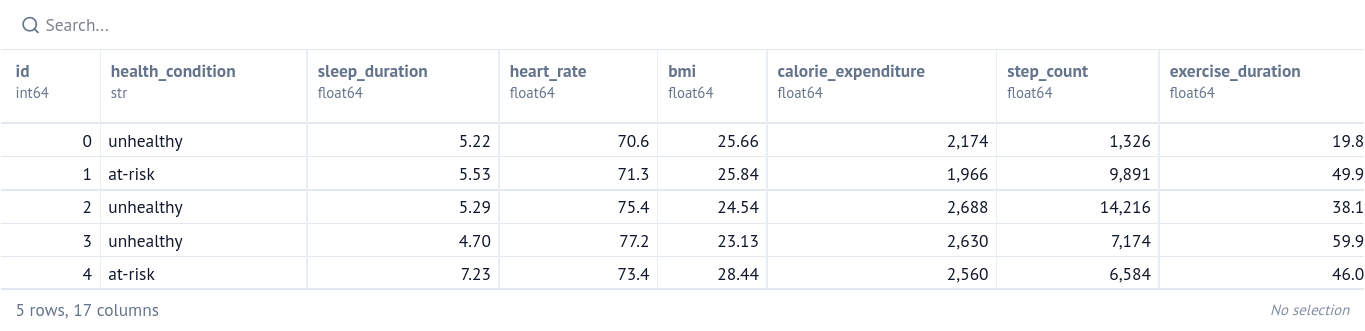

In [ ]:
def engineer_features(data) -> pd.DataFrame:
    copy = data.copy()
    copy["steps_per_minute"] = data["step_count"] / (data["exercise_duration"] + 1e-5)
    copy["calories_per_step"] = data["calorie_expenditure"] / (data["step_count"] + 1e-5)

    return copy

train_fe = engineer_features(train_data)
train_fe.head()

`cv_2` is a **controlled experiment**: it reuses the exact same models, `StratifiedKFold`, metric list, and sample-weight function as `cv_1` — the *only* difference is that the training data now includes the engineered features (`train_fe`). Any change in `cv_2` relative to `cv_1` is attributable to feature engineering, and nothing else.

In [ ]:
_trans = ColumnTransformer(
    transformers=[
        # Ordinal Pipeline
        ('ord', Pipeline([
            ('encoder', OrdinalEncoder(
                    categories=ord_categories,
                    handle_unknown="use_encoded_value",
                    unknown_value=-1
                )
            )
        ]), ord_cols),

        # Categorical Pipeline 
        ('cat', Pipeline([
            ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_cols)
    ],
    remainder="passthrough",
)

pp_2 = Preprocessor(train_fe, "health_condition")
pp_2.split_data(random_state=CONFIG["SEED"])
pp_2.fit(_trans)
pp_2.transform()
pp_2.encode_target(inplace=True, as_series=True)

X_2, y_2 = pp_2.get_split()

cv_2 = CrossValidator(
    models=models_1,
    metric_fns=metric_fns,
    cv_method=StratifiedKFold(n_splits=5, shuffle=True, random_state=CONFIG["SEED"]),
    sample_weight_fn=partial(compute_sample_weight, "balanced"),
    pi_kwargs = {'scoring':'balanced_accuracy', 'random_state': CONFIG["SEED"], 'n_jobs': 2, 'n_repeats': 3},
)

cv_2.fit(X_2["train"], y_2["train"])
view_confusion_matrices(cv_2, X_2, y_2, ncols=3, labels=pp_2.get_classes())

In [ ]:
cv_2.get_oof_metrics_df().sort_values(by="balanced_accuracy", ascending=False)

In [ ]:
_df, _ = aggregate_predictions(cv_2, X_2, y_2)
_df.sort_values(by="balanced_accuracy", ascending=False)

In [ ]:
top_k_permutation_scores(cv_2.get_perm_importances(), X_2["train"].columns.tolist(), k=10, ncols=2)

In [ ]:
per_class_shap_beeswarm(cv_2.get_models()[0][1], X_2, y_2, classes=pp_2.get_classes(), title="HistGradientBoost Shap Values Per Class")

In [ ]:
per_class_shap_beeswarm(cv_2.get_models()[1][1], X_2, y_2, classes=pp_2.get_classes(), title="XGBoost Shap Value Per Class")

In [ ]:
per_class_shap_beeswarm(cv_2.get_models()[2][1], X_2, y_2, classes=pp_2.get_classes(), title="LightGBM Shap Values Per Class")

### Feature engineering: the (controlled) verdict

Compare `cv_1` (raw features) and `cv_2` (engineered):

| Model | Balanced accuracy (raw) | Balanced accuracy (engineered) |
|---|---:|---:|
| `LightGBM` | 94.98% | 95.00% |
| `XGBoost` | 94.96% | 94.95% |
| `HistGradientBoost` | 94.94% | 94.95% |

The engineered features buy essentially nothing — **+0.03 points**, well within fold-to-fold noise. This is a **negative result**, and a valuable one:

- It is only interpretable *because* the experiment was controlled: identical folds, models, metric, and weights, with the data as the sole variable.
- The boosted models were already extracting the same signal from `sleep_duration`, `step_count`, and `exercise_duration` directly; the ratios add no information on top.
- It saved us from keeping two extra columns that complicate the pipeline for zero benefit.

This closes the experimentation loop: one change, measured fairly, verdict recorded — whether the outcome is positive or negative.

# 4. Creating a submission

In [ ]:
_trans = ColumnTransformer(
    transformers=[
        # Ordinal Pipeline
        ('ord', Pipeline([
            ('encoder', OrdinalEncoder(
                    categories=ord_categories,
                    handle_unknown="use_encoded_value",
                    unknown_value=-1
                )
            )
        ]), ord_cols),

        # Categorical Pipeline 
        ('cat', Pipeline([
            ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_cols)
    ],
    remainder="passthrough",
)

test_fe = engineer_features(test_data)

pp_full = Preprocessor(train_fe, "health_condition")
pp_full.fit(_trans)
pp_full.transform()
pp_full.encode_target()
X, y = pp_full.get_split()

best_model = clone(models_1[2][1]) # LightGBM
best_model.fit(X, y, sample_weight=compute_sample_weight("balanced", y))

X_test = pp_full.transform(test_fe)
preds = best_model.predict(X_test)
labels = pp_full._label_encoder.inverse_transform(preds)

Ancestor raised: An ancestor raised an exception (KeyError)

In [ ]:
def create_submission(sample_submission, target_name, labels, y_pred):
    sub = sample_submission.copy()
    sub[target_name] = labels 
    id_col = sample_submission["id"]
    sub.drop("id", axis=1, inplace=True)
    sub.index = id_col
    return sub

sub = create_submission(sample_sub, "health_condition", labels, preds)
sub.head()

In [ ]:
# sub.to_csv()

# 5. Where to Go from Here

This notebook covered the core workflow: EDA, validation, baselines, model
comparison, feature engineering, and submission. Two important topics we did not
cover in depth:

### Hyperparameter Tuning

The models we trained used default or lightly constrained settings. In practice,
tuning hyperparameters (e.g., `learning_rate`, `n_estimators`, `max_depth` for
gradient boosting) can yield meaningful improvements. Two common approaches:

- **Grid Search**: exhaustively tries every combination of a predefined parameter
  grid. Reliable but slow.
- **Random Search**: samples random combinations from a distribution. Often finds
  good settings faster than grid search when you have many parameters.

Scikit-learn's `GridSearchCV` and `RandomizedSearchCV` integrate directly with
cross-validation, so you get a validated score for every parameter combination.

`optuna` is also common framework that is used for hyperparameter optimization by ML practitioners. Something worth looking into.

### Ensembling

Instead of picking a single best model, **ensembling** combines predictions from
multiple models to reduce variance and improve robustness. Common strategies:

- **Averaging**: average the predicted probabilities of several models before
  taking `argmax`.
- **Majority voting**: each model casts a hard vote; the class with the most votes
  wins.
- **Stacking**: train a meta-learner on the out-of-fold predictions of base models.

Ensembling is one of the most reliable ways to squeeze out extra performance in
Kaggle competitions. Libraries like `VotingClassifier` and `StackingClassifier`
in scikit-learn make this straightforward.